In [1]:
%pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 9.3 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15703 sha256=de8217c489caa02750b1530b3629a559829af55444d8a6b4f211440ff3bfa839
  Stored in directory: c:\users\jay\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------

In [6]:
import yfinance as yf

# Create a ticker object
aapl = yf.Ticker("AAPL")

# Get historical market data (defaults to 1mo, or use period="1y", "max", etc.)
hist = aapl.history(period="1y")
print(hist)


                                 Open        High         Low       Close  \
Date                                                                        
2025-03-06 00:00:00-05:00  233.422640  236.827797  232.148195  234.308777   
2025-03-07 00:00:00-05:00  234.089740  240.322569  233.741253  238.032562   
2025-03-10 00:00:00-04:00  234.517865  235.135185  223.246996  226.492844   
2025-03-11 00:00:00-04:00  222.838766  224.859955  216.506364  219.881653   
2025-03-12 00:00:00-04:00  219.184697  220.787711  213.977397  216.038406   
...                               ...         ...         ...         ...   
2026-03-02 00:00:00-05:00  262.410004  266.529999  260.200012  264.720001   
2026-03-03 00:00:00-05:00  263.480011  265.559998  260.130005  263.750000   
2026-03-04 00:00:00-05:00  264.649994  266.149994  261.420013  262.519989   
2026-03-05 00:00:00-05:00  260.790009  261.559998  257.250000  260.290009   
2026-03-06 00:00:00-05:00  258.739990  258.760010  254.369995  256.970001   

In [10]:
# Fetch Reliance Industries data
reliance = yf.download("RELIANCE.NS", start="2023-01-01", end="2026-01-01")
print(reliance.head())


[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2023-01-02  1175.889648  1177.304802  1163.244669  1164.066352     5316175
2023-01-03  1167.284668  1174.565828  1163.062148  1170.936659     7658932
2023-01-04  1149.709595  1169.110728  1147.632506  1167.261851     9264891
2023-01-05  1147.655151  1157.857903  1143.067373  1151.969076    13637099
2023-01-06  1158.086304  1163.130627  1149.595501  1153.407240     6349597


In [11]:
import yfinance as yf
import pandas as pd
import os
import time

# 1. Create a directory to store your datasets
folder_name = "Nifty50_Historical_Data"
os.makedirs(folder_name, exist_ok=True)

# 2. Define the Nifty 50 Tickers 
# (You must add '.NS' to the end of the symbol to tell Yahoo Finance you want the NSE data)
nifty50_tickers = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS", 
    "ITC.NS", "SBIN.NS", "BHARTIARTL.NS", "BAJFINANCE.NS", "LT.NS",
    "KOTAKBANK.NS", "AXISBANK.NS", "MARUTI.NS", "SUNPHARMA.NS", "TATAMOTORS.NS"
    # Note: I have included the top 15 here to keep the code short. 
    # You can easily paste the remaining 35 tickers into this list!
]

# 3. Loop through the list and download 5 years of data
print("Starting download process...")

for ticker in nifty50_tickers:
    print(f"Fetching 5-year data for {ticker}...")
    
    try:
        # Download the data. 'period="5y"' gets the last 5 years automatically.
        stock_data = yf.download(ticker, period="5y")
        
        # Check if the dataframe is empty (in case a ticker is misspelled)
        if not stock_data.empty:
            # Save it to your folder
            file_path = os.path.join(folder_name, f"{ticker}_5y.csv")
            stock_data.to_csv(file_path)
            print(f"  -> Saved to {file_path}")
        else:
            print(f"  -> Warning: No data found for {ticker}")
            
    except Exception as e:
        print(f"  -> Error downloading {ticker}: {e}")
        
    # Add a 1-second pause to avoid getting temporarily blocked by Yahoo Finance
    time.sleep(1)

print("\nAll Nifty 50 downloads complete!")

Starting download process...
Fetching 5-year data for RELIANCE.NS...


[*********************100%***********************]  1 of 1 completed


  -> Saved to Nifty50_Historical_Data\RELIANCE.NS_5y.csv
Fetching 5-year data for TCS.NS...


[*********************100%***********************]  1 of 1 completed


  -> Saved to Nifty50_Historical_Data\TCS.NS_5y.csv
Fetching 5-year data for HDFCBANK.NS...


...

  -> Saved to Nifty50_Historical_Data\MARUTI.NS_5y.csv
Fetching 5-year data for SUNPHARMA.NS...


[*********************100%***********************]  1 of 1 completed


  -> Saved to Nifty50_Historical_Data\SUNPHARMA.NS_5y.csv
Fetching 5-year data for TATAMOTORS.NS...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


  -> Warning: No data found for TATAMOTORS.NS

All Nifty 50 downloads complete!


In [12]:
        stock_data = yf.download('TMCV.NS', period="5y")
        
        # Check if the dataframe is empty (in case a ticker is misspelled)
        if not stock_data.empty:
            # Save it to your folder
            file_path = os.path.join(folder_name, "TMCV.NS_5y.csv")
            stock_data.to_csv(file_path)
            print(f"  -> Saved to {file_path}")

[*********************100%***********************]  1 of 1 completed

  -> Saved to Nifty50_Historical_Data\TMCV.NS_5y.csv


In [16]:
import pandas as pd
import numpy as np

file_path = "Nifty50_Historical_Data/RELIANCE.NS_5y.csv"
df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
# 2. Daily Return (Momentum)
# Calculates the percentage change from yesterday's close to today's close.
df['Daily_Return'] = df['Close'].pct_change()

# 3. Simple Moving Averages (Trend)
# Averages out the price over the last 10 days and 50 days to smooth out the noise.
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# 4. Volatility (Risk)
# Calculates the standard deviation of the daily returns over the last 10 days.
# High volatility means chaotic price swings; low means stable.
df['Volatility_10'] = df['Daily_Return'].rolling(window=10).std()

# 5. Price Action / Candle Shape (Market Psychology)
# Daily_Range shows how far the price stretched top-to-bottom today.
df['Daily_Range'] = df['High'] - df['Low']
# Body_Size shows who won the day (Positive = Buyers, Negative = Sellers).
df['Body_Size'] = df['Close'] - df['Open']
# 6. Creating the Target (What you are trying to predict)
# To train your model to predict TOMORROW'S close, you must shift the Close column UP by one row.
# This aligns today's features (SMA, Volatility, etc.) with tomorrow's actual price.
df['Target_Next_Close'] = df['Close'].shift(-1)
# 7. Clean up the data
# Calculating rolling averages (like a 50-day SMA) means your first 49 days will have 'NaN' (missing data).
# Shifting the target variable also leaves the very last row without a target.
# We must drop all rows with NaN values before feeding this to a machine learning model.
df.dropna(inplace=True)

# Let's look at the newly engineered dataset!

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1186 entries, 25-05-2021 to 06-03-2026
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Close              1186 non-null   float64
 1   High               1186 non-null   float64
 2   Low                1186 non-null   float64
 3   Open               1186 non-null   float64
 4   Volume             1186 non-null   float64
 5   Daily_Return       1186 non-null   float64
 6   SMA_10             1186 non-null   float64
 7   SMA_50             1186 non-null   float64
 8   Volatility_10      1186 non-null   float64
 9   Daily_Range        1186 non-null   float64
 10  Body_Size          1186 non-null   float64
 11  Target_Next_Close  1186 non-null   float64
dtypes: float64(12)
memory usage: 120.5+ KB


In [19]:
X=df.drop("Target_Next_Close",axis=1)
y=df['Target_Next_Close']

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: ylabel='Volatility_10'>

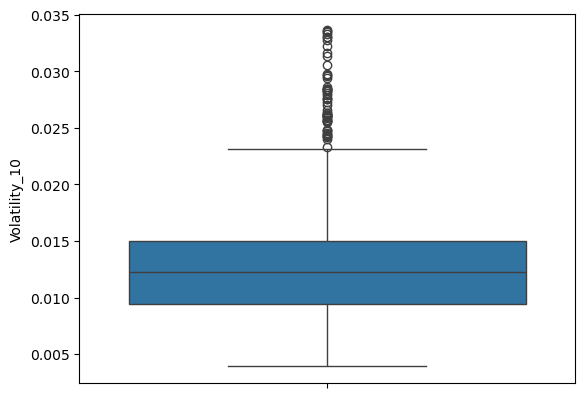

In [43]:
sns.boxplot(data=df['Volatility_10'])

<Axes: ylabel='Daily_Return'>

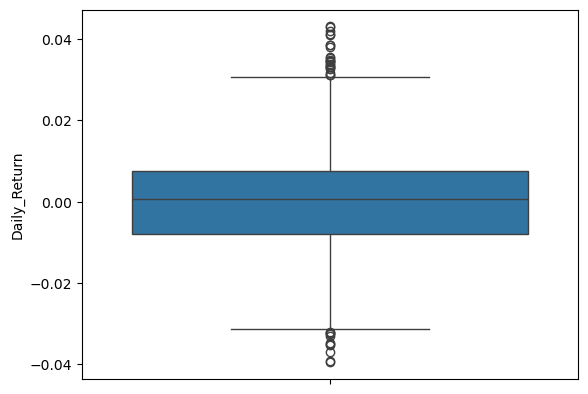

In [42]:
sns.boxplot(data=df['Daily_Return'])

In [38]:
df[df['Daily_Return']>0.04]

,Close,High,Low,Open,Volume,Daily_Return,SMA_10,SMA_50,Volatility_10,Daily_Range,Body_Size,Target_Next_Close
Date,,,,,,,,,,,,
06-09-2021,1086.796143,1089.753727,1047.665132,1051.077656,30664428.0,0.041013,1023.089978,970.351356,0.012768,42.088595,35.718487,1103.677246
10-03-2022,1071.143677,1077.013352,1016.564962,1017.406840,20414228.0,0.053053,1055.848559,1090.712048,0.031243,60.448390,53.736837,1088.502441
18-05-2022,1150.793579,1155.685016,1106.589155,1107.999707,16551828.0,0.042003,1145.711133,1164.790735,0.023121,49.095861,42.793872,1154.979736
23-05-2022,1194.156250,1203.233727,1138.440064,1143.217645,21793091.0,0.058310,1131.489746,1171.154072,0.030148,64.793663,50.938605,1186.170898
03-04-2023,1064.116455,1069.777071,1029.262976,1029.399903,28171201.0,0.043115,1025.887134,1068.744865,0.019870,40.514095,34.716552,1064.299072
04-06-2024,1499.228516,1503.372890,1448.280652,1472.104322,21527942.0,0.055876,1448.466760,1441.927649,0.020656,55.092238,27.124194,1387.009155
27-06-2024,1502.901367,1507.814951,1434.507557,1435.425809,22014882.0,0.041175,1457.547046,1439.956245,0.015983,73.307394,67.475558,1519.305054
29-04-2025,1363.354980,1369.131835,1314.948213,1334.669498,31104496.0,0.052599,1277.931091,1236.398938,0.017852,54.183622,28.685482,1394.131958
13-05-2025,1430.785522,1433.275577,1394.430722,1394.430722,10674081.0,0.043058,1401.622070,1269.352327,0.023295,38.844855,36.354800,1410.068237


In [28]:
df.drop('31-05-2021',axis=0)

,Close,High,Low,Open,Volume,Daily_Return,SMA_10,SMA_50,Volatility_10,Daily_Range,Body_Size,Target_Next_Close
Date,,,,,,,,,,,,
25-05-2021,900.355774,911.306181,898.700775,910.489956,8551760.0,-0.008439,890.028888,905.274607,0.009130,12.605405,-10.134182,890.153625
26-05-2021,890.153625,905.502270,888.725306,905.230195,14780102.0,-0.011331,891.704321,903.207413,0.010058,16.776964,-15.076570,893.282288
27-05-2021,893.282288,897.567245,891.128535,895.526772,7480204.0,0.003515,893.377484,901.203250,0.010056,6.438710,-2.244484,896.025574
28-05-2021,896.025574,903.688532,889.745539,893.395675,26819294.0,0.003071,896.231842,899.336476,0.009083,13.942993,2.629899,949.847900
01-06-2021,979.547546,993.785282,945.426862,953.112488,59124142.0,0.031268,912.439746,899.414467,0.021455,48.358420,26.435058,983.447082
...,...,...,...,...,...,...,...,...,...,...,...,...
27-02-2026,1406.800049,1412.900024,1391.900024,1398.500000,16683858.0,0.005935,1421.200012,1467.620002,0.014139,21.000000,8.300049,1393.900024
02-03-2026,1393.900024,1410.400024,1388.099976,1398.000000,12031440.0,-0.009170,1418.630017,1464.610002,0.013018,22.300048,-4.099976,1358.000000
04-03-2026,1358.000000,1378.599976,1341.500000,1375.500000,23728722.0,-0.025755,1410.720020,1460.882002,0.013978,37.099976,-17.500000,1345.000000


In [32]:
df=df[df['Daily_Return']<0.06]

In [33]:
df[df['Daily_Return']>0.06]

,Close,High,Low,Open,Volume,Daily_Return,SMA_10,SMA_50,Volatility_10,Daily_Range,Body_Size,Target_Next_Close
Date,,,,,,,,,,,,


In [36]:
df=df[df['Daily_Return']>-0.04]

In [41]:
df=df[df['Daily_Return']<=0.05]

<Axes: ylabel='Daily_Range'>

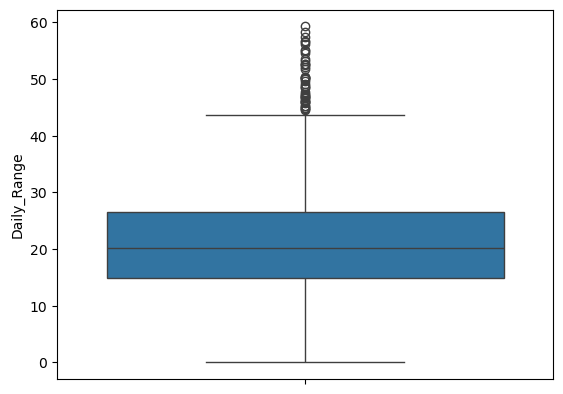

In [47]:
sns.boxplot(data=df['Daily_Range'])

In [46]:
df=df[df['Daily_Range']<60]

<Axes: ylabel='Body_Size'>

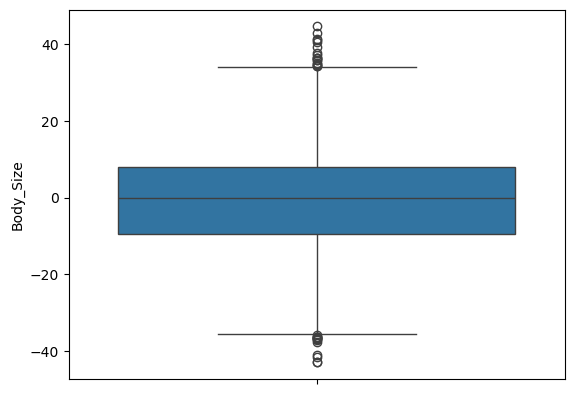

In [57]:
sns.boxplot(data=df['Body_Size'])

In [56]:
df=df[df['Body_Size']>-45]

In [58]:
X=df.drop('')

,Close,High,Low,Open,Volume,Daily_Return,SMA_10,SMA_50,Volatility_10,Daily_Range,Body_Size
Date,,,,,,,,,,,
25-05-2021,900.355774,911.306181,898.700775,910.489956,8551760.0,-0.008439,890.028888,905.274607,0.009130,12.605405,-10.134182
26-05-2021,890.153625,905.502270,888.725306,905.230195,14780102.0,-0.011331,891.704321,903.207413,0.010058,16.776964,-15.076570
27-05-2021,893.282288,897.567245,891.128535,895.526772,7480204.0,0.003515,893.377484,901.203250,0.010056,6.438710,-2.244484
28-05-2021,896.025574,903.688532,889.745539,893.395675,26819294.0,0.003071,896.231842,899.336476,0.009083,13.942993,2.629899
31-05-2021,949.847900,954.472877,902.328310,902.328310,56469931.0,0.060068,903.373389,898.948339,0.020152,52.144567,47.519590
...,...,...,...,...,...,...,...,...,...,...,...
27-02-2026,1406.800049,1412.900024,1391.900024,1398.500000,16683858.0,0.005935,1421.200012,1467.620002,0.014139,21.000000,8.300049
02-03-2026,1393.900024,1410.400024,1388.099976,1398.000000,12031440.0,-0.009170,1418.630017,1464.610002,0.013018,22.300048,-4.099976
04-03-2026,1358.000000,1378.599976,1341.500000,1375.500000,23728722.0,-0.025755,1410.720020,1460.882002,0.013978,37.099976,-17.500000


In [59]:
X=df.drop("Target_Next_Close",axis=1)
y=df['Target_Next_Close']

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [61]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [62]:
from sklearn.linear_model import ElasticNet
base_elastic_model = ElasticNet()
param_grid = {'alpha':[0.1,1,5,10,50,100],
              'l1_ratio':[.1, .5, .7, .9, .95, .99, 1]}

In [63]:
from sklearn.model_selection import GridSearchCV
grid_model = GridSearchCV(estimator=base_elastic_model,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=1)

In [64]:
grid_model.fit(scaled_X_train,y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits


C:\Users\Jay\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.219e+03, tolerance: 1.678e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\Jay\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.000e+03, tolerance: 1.639e+03
  model = cd_fast.enet_coordinate_descent(
C:\Users\Jay\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.812e+03, tolerance: 1.6

,estimator,ElasticNet()
,param_grid,"{'alpha': [0.1, 1, ...], 'l1_ratio': [0.1, 0.5, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [65]:
y_predict=grid_model.predict(scaled_X_test)

In [68]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mean_absolute_error(y_test,y_predict)

12.38944929427123

In [69]:
r2_score(y_test,y_predict)

0.9899565832876623

In [72]:
y_predict

array([1451.81516007, 1114.28180323, 1247.32675158, 1178.05674927,
       1106.62735852, 1550.01193014, 1179.0493106 , 1084.09408343,
        966.20686619,  958.12733441, 1159.89121803, 1541.26321119,
       1219.06525294, 1211.47121251, 1150.17692722, 1134.93086978,
       1402.3693818 , 1065.91597184, 1179.29743886, 1244.14247662,
       1539.2964173 , 1417.91750392,  948.54996801, 1212.20562286,
       1452.22903822, 1165.92379401, 1167.39505462, 1091.48931747,
       1517.87527213, 1089.7117679 , 1171.97703318, 1204.10261584,
       1157.62713185, 1096.82558867, 1103.80884142, 1273.8307456 ,
       1144.69222667, 1091.37865947, 1064.96128174, 1145.21654851,
       1190.2601407 , 1230.15349768, 1238.02308642, 1055.9883496 ,
       1412.20960546, 1157.3841507 ,  907.17201538, 1584.67573424,
       1142.11790202, 1079.22998994, 1062.38767056, 1413.39015981,
        972.53847272, 1417.72056318, 1221.61203549, 1088.09939357,
       1143.75757422, 1385.0303686 , 1163.55790154, 1229.54634

In [79]:
# Assuming you have already run:
# grid_model.fit(X_train, y_train)

# 1. Extract the absolute best model from the Grid Search
best_elastic_model = grid_model.best_estimator_

# 2. Reveal the optimal "punishments" the model chose
print("--- WINNING HYPERPARAMETERS ---")
print(f"Optimal Alpha: {base_elastic_model.alpha}")
print(f"Optimal L1 Ratio: {base_elastic_model.l1_ratio}\n")

# 3. SOLVE THE ERROR: Reveal the exact 11 features it requires
print("--- THE 11 REQUIRED FEATURES ---")
expected_features = best_elastic_model.feature_names_in_
for i, feature in enumerate(expected_features, 1):
    print(f"{i}. {feature}")

--- WINNING HYPERPARAMETERS ---
Optimal Alpha: 1.0
Optimal L1 Ratio: 0.5

--- THE 11 REQUIRED FEATURES ---


AttributeError: 'ElasticNet' object has no attribute 'feature_names_in_'

In [80]:
# This looks at the DataFrame before it lost its column names
print("The 11 features are:")
print(X_train.columns.tolist())

The 11 features are:
['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'SMA_10', 'SMA_50', 'Volatility_10', 'Daily_Range', 'Body_Size']


In [81]:
import pandas as pd
import numpy as np

# 1. Create the dictionary with your EXACT 11 features
# The keys must match your list perfectly
random_market_data = {
    'Close': [2950.00],
    'High': [2980.00],
    'Low': [2930.00],
    'Open': [2940.00],
    'Volume': [5500000],
    'Daily_Return': [0.0034],
    'SMA_10': [2910.50],
    'SMA_50': [2850.00],
    'Volatility_10': [0.012],
    'Daily_Range': [50.00],
    'Body_Size': [10.00]
}

# 2. Convert to a pandas DataFrame
new_data_df = pd.DataFrame(random_market_data)

# 3. CRITICAL: Enforce the exact column order!
# Scikit-learn scalers do not read column names; they only read the order.
# This ensures your new data perfectly matches the shape of X_train.
expected_order = ['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'SMA_10', 'SMA_50', 'Volatility_10', 'Daily_Range', 'Body_Size']
new_data_df = new_data_df[expected_order]

# 4. Transform the data using your fitted scaler
# (Assuming your scaler variable is named 'scaler')
scaled_new_data = scaler.transform(new_data_df)

# 5. Make the prediction using the GridSearchCV object
# grid_model automatically uses the best ElasticNet parameters it found
final_prediction = grid_model.predict(scaled_new_data)

# 6. Display the result
print("--- PREDICTION RESULTS ---")
print(f"Based on the provided data, the model predicts tomorrow's closing price will be: ₹{final_prediction[0]:.2f}")

--- PREDICTION RESULTS ---
Based on the provided data, the model predicts tomorrow's closing price will be: ₹2923.26


In [82]:
import pandas as pd
import numpy as np

# 1. Real end-of-day data for RELIANCE.NS
reliance_live_data = {
    'Close': [1389.40],
    'High': [1399.00],
    'Low': [1353.10],
    'Open': [1358.00],
    'Volume': [118674525],
    'Daily_Return': [0.0231],
    'SMA_10': [1397.70],
    'SMA_50': [1450.50],
    'Volatility_10': [0.0253],
    'Daily_Range': [45.90],
    'Body_Size': [31.40]
}

# 2. Convert to DataFrame
live_df = pd.DataFrame(reliance_live_data)

# 3. Enforce the exact column order
expected_order = ['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'SMA_10', 'SMA_50', 'Volatility_10', 'Daily_Range', 'Body_Size']
live_df = live_df[expected_order]

# 4. Transform using your fitted scaler
scaled_live_data = scaler.transform(live_df)

# 5. Get the prediction!
reliance_prediction = grid_model.predict(scaled_live_data)[0]

print("--- RELIANCE.NS LIVE PREDICTION ---")
print(f"Today's Close: ₹1389.40")
print(f"Your model predicts the next closing price will be: ₹{reliance_prediction:.2f}")

--- RELIANCE.NS LIVE PREDICTION ---
Today's Close: ₹1389.40
Your model predicts the next closing price will be: ₹1388.21
